<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

# 01 · AtomicData and Batch

> **DRAFT: technical checks complete; human cell review pending**

**Goal:** Start from familiar ASE molecules, convert one structure to `AtomicData`, build the same object directly from tensors, then pack molecules with different atom counts into one CUDA `Batch`.

**Core concepts**

- `AtomicData` stores one molecular structure as validated, graph-aware tensors.
- `Batch` packs several `AtomicData` records while keeping each molecule separate.
- Node, edge, and system fields state whether a value belongs to an atom, a neighbor relation, or a complete molecule.

## Where NVIDIA ALCHEMI fits

[ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together Python building blocks, accelerated kernels, and deployable services for atomistic workflows.

- **ALCHEMI Toolkit** is a GPU-first Python framework with a unified, composable API for MLIPs and custom models. It provides GPU-native atomic data and batching, model adapters, MD classes, hooks, model training,  and single- to multi-GPU pipelines.   
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit) · [Docs](https://nvidia.github.io/nvalchemi-toolkit/) · Apache 2.0 license

- **Toolkit-Ops** supplies GPU-optimized, batched operations for neighbor lists, dynamics, dispersion, and electrostatics, with PyTorch and JAX bindings.    
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Docs](https://nvidia.github.io/nvalchemi-toolkit-ops/) · Apache 2.0 license

- **ALCHEMI NIM microservices** package supported atomistic workflows as cloud-ready services. The current catalog includes Batched Geometry Relaxation for structural optimization and Batched Molecular Dynamics.  Self-hosting uses an NVIDIA AI Enterprise license.   
 [Transparency card](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/1.0.0/ai-transparency-card/overview.html) · [Docs](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html)

In [10]:
import helpers
import pandas as pd
import torch
from ase.build import molecule
from ase.collections import g2, s22
from nvalchemi.data import AtomicData, Batch
from pydantic import ValidationError
from pymatviz import StructureWidget

helpers.start_tutorial()
torch.set_grad_enabled(False)
device = torch.device("cuda")
print(f"Lesson device: {torch.cuda.get_device_name(device)}")

Lesson device: NVIDIA RTX 4000 SFF Ada Generation


## Three different molecules, one Toolkit operation

How can one tensor operation accept water with 3 atoms, methane with 5, and ethanol with 9?

The official Toolkit ASE example uses these three molecules to introduce conversion and batching. We will build the same input path in smaller steps.

In [12]:
from ase.atoms import Atoms


from typing import Any


molecule_names = ["H2O", "CH4", "CH3CH2OH"]
molecules = [molecule(name) for name in molecule_names]
[(name, atoms.get_chemical_formula(), len(atoms)) for name, atoms in zip[tuple[str, Atoms | Any]](molecule_names, molecules, strict=True)]

TypeError: type 'zip' is not subscriptable

ASE builds these familiar molecules on the CPU. `AtomicData.from_atoms(..., device=device)` converts their fields to CUDA tensors. The main Toolkit path stays on the GPU from that point onward.

## Why evaluate molecules as a batch?

Evaluate energy and forces for 2,048 molecules sampled with a fixed seed from ASE's G2 and S22 collections. The source pool spans water with 3 atoms to an adenine–thymine complex with 30 atoms.

The four routes perform the same model work: 2,048 one-molecule calls or one `Batch` call, on CPU and GPU. Neighbor data are prepared before timing.

Output()

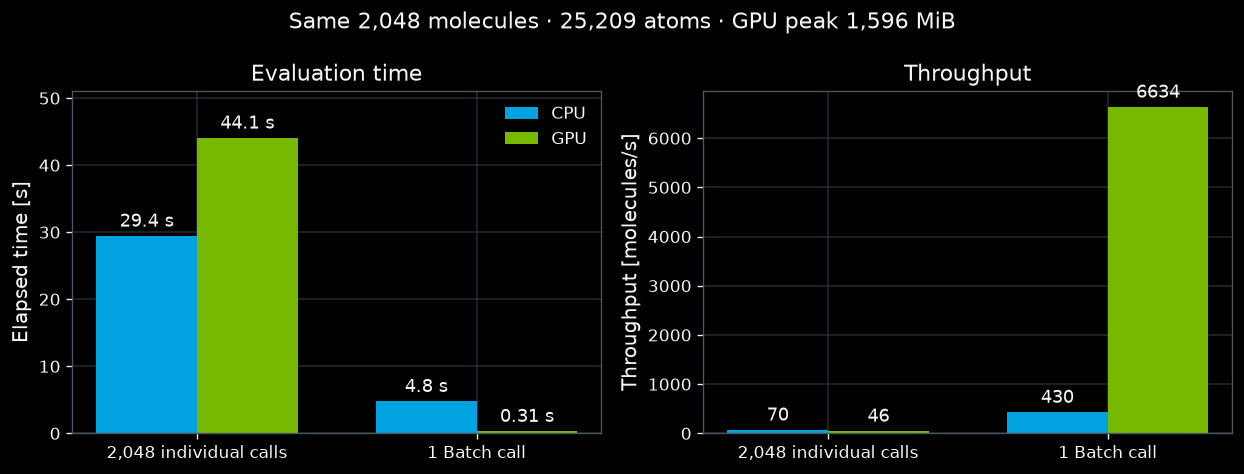

In [9]:
benchmark_molecules = [
    g2["H2O"], g2["CH4"], g2["CH3CH2OH"],
    g2["C6H6"], g2["trans-butane"],
    s22["Adenine-thymine_Watson-Crick_complex"],
]
opening_timing = helpers.show_batched_speedup(
    benchmark_molecules, batch_size=2_048, seed=7
)

The left panel reports response time; the right reports throughput. The figure also reports peak GPU memory for the batched call.

This is the result we will unpack: how Toolkit represents one molecule, how a `Batch` keeps molecules separate, and how one model call evaluates the full collection.

## Course map

The left column is the course order. The right column groups the work these lessons enable. Green marks Part 01.

![ALCHEMI Toolkit curriculum. Part 01 teaches the data and batching foundation used by later data, model, simulation, training, and multi-GPU workflows.](../../shared/curriculum-map-01.svg)

**Open a lesson**

- [01 · AtomicData and Batch](atomicdata-and-batch.ipynb) · [02 · Zarr data loading](../02-zarr-data-loading/zarr-data-loading.ipynb) · [03 · Models and composition](../03-model-interfaces-composition/model-interfaces-composition.ipynb) · [04 · Hooks](../04-hooks/hooks.ipynb)
- [05 · BaseDynamics](../05-base-dynamics/base-dynamics.ipynb) · [06 · GPU pipelines](../06-gpu-pipelines-profiling/gpu-pipelines-profiling.ipynb) · [07 · Training](../07-training-finetuning/training-finetuning.ipynb) · [08 · Domain decomposition](../08-domain-decomposition/domain-decomposition.ipynb)

Part 01 builds the inputs used throughout the course: one atomic system as `AtomicData`, and many systems as a `Batch`.

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#F2F3F1;color:#1B1E20;border:1px solid #D6D9D4;border-radius:8px;padding:0.78rem 0.95rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#725B22;font-size:0.78rem;font-weight:700;letter-spacing:0.03em;margin-bottom:0.25rem;">💡 Highlight</div>
  <div style="min-width:0;font-size:0.98rem;overflow-wrap:anywhere;">Toolkit components share one data container. <code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">AtomicData</code> holds one atomic system. <code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">Batch</code> holds several independent systems for models, hooks, and dynamics.</div>
</div>

## Inspect one ASE molecule

`ase.build.molecule(...)` constructs common molecules from ASE's G2 collection. We start with water and inspect the `Atoms` object that carries its elements, coordinates, cell, and periodicity.

In [2]:
water = molecules[0]

NameError: name 'molecules' is not defined

In [ ]:
print(water)

In [ ]:
water.get_chemical_formula(), len(water), water.pbc.tolist()

Rotate the water molecule. How do the three atoms form its bent geometry?

In [11]:
StructureWidget(
    structure_string=helpers.atoms_to_xyz(water),
    show_bonds=True,
    show_controls=True,
    background_color="#111619",
    background_opacity=1.0,
    style="width:100%; height:440px; border-radius:10px;",
)

### Structure objects and file formats

Toolkit converts structures after a chemistry library creates or reads them:

| In-memory object | Toolkit converter |
|---|---|
| ASE `Atoms` | `AtomicData.from_atoms(...)` |
| pymatgen `Structure` or `Molecule` | `AtomicData.from_structure(...)` |

The frozen course environment follows the ASE path. A pymatgen-enabled project uses a similar conversion through `AtomicData.from_structure(...)`:

```python
from pymatgen.core import Molecule
pm_water = Molecule(["O", "H", "H"], water.positions)
pm_water_data = AtomicData.from_structure(pm_water, device=device)
```

ASE and pymatgen own file parsing. Toolkit receives the in-memory structure.

## From one molecule to a `Batch`

<!-- CORE-EXCERPT: atomicdata-conversion -->

A chemistry library gives Toolkit one molecule or structure. `AtomicData` stores that system as graph-aware tensor data. Atoms are nodes. Positions and elements are node fields; cell and periodicity describe the complete system. Neighbor construction adds the interaction edges requested by a model later in the course.

`Batch` packs several `AtomicData` records into graph-aware tensor storage. `AtomicData.from_atoms(..., device=device)` is the CUDA handoff in this lesson.

How do the scientific object and the two Toolkit objects connect?

<img src="assets/atomicdata-batch-ladder.svg" alt="A molecule or structure is converted into one AtomicData object. Several AtomicData objects are packed into one Batch." style="display:block;box-sizing:border-box;width:100%;max-width:760px;height:auto;border:0;">

`AtomicData` holds one molecule. `Batch.num_graphs` counts the molecules packed together. `batch_idx` assigns every atom row to a molecule, and `batch_ptr` marks the start and end of each molecule in the packed tensors.

In [ ]:
water_data = AtomicData.from_atoms(water, device=device)
water_data.num_nodes, water_data.device

In [ ]:
field_names = ["atomic_numbers", "positions", "cell", "pbc"]
field_table = pd.DataFrame(
    {
        "field": field_names,
        "shape": [tuple(getattr(water_data, name).shape) for name in field_names],
        "level": ["node", "node", "system", "system"],
        "unit": ["integer", "Å", "Å", "Boolean"],
        "dtype": [getattr(water_data, name).dtype for name in field_names],
        "device": [getattr(water_data, name).device for name in field_names],
    }
)

In [ ]:
field_table.set_index("field")

In [ ]:
{
    "node fields": sorted(water_data.node_properties),
    "edge fields": sorted(water_data.edge_properties),
    "system fields": sorted(water_data.system_properties),
}

`positions` and `atomic_numbers` have three rows because water has three atoms. `cell` and `pbc` describe the complete structure.

`from_atoms(...)` also carries masses, categories, and velocities as node fields. The edge group is empty because this lesson has not built model-specific neighbors.

The converter validates the field shapes and places every tensor on the requested device.

## Construct `AtomicData` directly from tensors

The public constructor needs two fields: positions with shape `[V, 3]` and atomic numbers with shape `[V]`. We use the same water geometry so the direct and ASE paths can be compared.

Direct construction is useful when a reader or simulation code already supplies tensors. The constructor validates the shapes and keeps the data on one device.

In [ ]:
manual_water = AtomicData(
    positions=torch.as_tensor(water.positions, dtype=torch.float32, device=device),
    atomic_numbers=torch.as_tensor(water.numbers, dtype=torch.int32, device=device),
)

In [ ]:
manual_water.num_nodes, manual_water.device, manual_water.dtype

In [ ]:
{
    "same elements": torch.equal(manual_water.atomic_numbers, water_data.atomic_numbers),
    "same positions": torch.allclose(manual_water.positions, water_data.positions),
}

Both routes produce `AtomicData`. `from_atoms(...)` also transfers ASE fields such as cell and periodicity. Direct construction gives a tensor-producing reader precise control over every supplied field.

### Validation catches an incomplete atom selection

A custom converter selects an O–H fragment from water. The conversion code applies the atom mask to the coordinates and leaves the element array unchanged. The two node fields now describe different atom counts.

In [ ]:
atom_mask = [True, True, False]
broken_conversion = {
    "positions": torch.as_tensor(water.positions[atom_mask], dtype=torch.float32, device=device),
    "atomic_numbers": torch.as_tensor(water.numbers, dtype=torch.int32, device=device),
}

In [ ]:
try:
    AtomicData(**broken_conversion)
except ValidationError as error:
    print(error.errors()[0]["msg"])

Validation stops because `positions` has two rows and `atomic_numbers` has three. Apply the same atom mask to every node field:

In [ ]:
fragment_data = AtomicData(
    positions=broken_conversion["positions"],
    atomic_numbers=torch.as_tensor(water.numbers[atom_mask], dtype=torch.int32, device=device),
)
fragment_data.positions.shape, fragment_data.atomic_numbers.shape

Both node fields now describe the same two atoms, so construction succeeds. Validation checks structural consistency at the conversion boundary.

## Pack three ASE molecules into one `Batch`

<!-- CORE-EXCERPT: batch-construction-and-boundaries -->

Convert each molecule on CUDA, then pack the three `AtomicData` records in input order. `Batch.from_data_list(...)` concatenates fields at each storage level and keeps each molecule as a separate graph. Here, `num_graphs` is the molecule count.

In [ ]:
molecule_data = [
    AtomicData.from_atoms(atoms, device=device) for atoms in molecules
]

In [ ]:
example_batch = Batch.from_data_list(molecule_data, device=device)
example_batch.num_graphs, example_batch.num_nodes, example_batch.device

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;background:#111619;color:#F3F4F6;border:1px solid #2E353B;border-radius:10px;padding:0.9rem 1rem;line-height:1.45;overflow-wrap:anywhere;">
  <div style="color:#76B900;font-size:0.72rem;font-weight:700;letter-spacing:0.055em;margin-bottom:0.45rem;">ALCHEMI TOOLKIT API</div>
  <code style="display:block;color:#FFFFFF;font-size:1.02rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">Batch.from_data_list(data_list, device=device)</code>
  <div style="border-top:1px solid #2E353B;margin-top:0.7rem;padding-top:0.65rem;color:#CDD2D8;font-size:0.92rem;">
    <div><strong style="color:#F3F4F6;">Input</strong> · a list of <code>AtomicData</code> objects</div>
    <div style="margin-top:0.25rem;"><strong style="color:#F3F4F6;">Result</strong> · one <code>Batch</code> with packed fields and graph boundaries</div>
  </div>
</div>

In [ ]:
example_counts = example_batch.num_nodes_per_graph.tolist()
example_counts

In [ ]:
example_ptr = example_batch.batch_ptr.tolist()
example_ptr

In [ ]:
example_batch.batch_idx

`num_nodes_per_graph` gives the atom counts `[3, 5, 9]`.
`batch_ptr` gives their boundaries `[0, 3, 8, 17]`.
`batch_idx` assigns each of the 17 atom rows to molecule 0, 1, or 2.

How does one `Batch` lay out the atom rows for three molecules with different sizes?

In [ ]:
labels = ["Water", "Methane", "Ethanol"]

In [ ]:
helpers.plot_batch_ownership(
    example_batch.atomic_numbers,
    example_batch.batch_idx,
    example_batch.batch_ptr,
    labels,
);

Each tile is one atom row. The colored bands show the molecule that owns that row. The row labels come from `batch_idx`; the vertical boundaries come from `batch_ptr`.

<!-- REVISE — GRAPHIC: confirm element labels and boundary text remain legible at notebook width. -->

### Recover molecules from a `Batch`

<!-- CORE-EXCERPT: batch-recovery -->

`Batch` keeps input order. `get_data(1)` returns methane as one `AtomicData` object. `index_select(...)` builds a smaller `Batch`, and `to_data_list()` recovers every molecule as a separate `AtomicData` object.

In [ ]:
methane_data = example_batch.get_data(1)
{"molecule": labels[1], "atoms": methane_data.num_nodes, "device": methane_data.device}

In [ ]:
selected_batch = example_batch.index_select([0, 2])
selected_batch.num_nodes_per_graph, selected_batch.device

## Add one molecule field and one atom field

`Batch.add_key(...)` updates the batch in place. It receives one tensor per molecule. A system field has one value per molecule. A node field has one value per atom. Toolkit concatenates each list and records its level.

In [ ]:
example_batch.add_key(
    "molecule_id",
    [torch.tensor([index], device=device) for index in range(example_batch.num_graphs)],
    level="system",
)

In [ ]:
example_batch.add_key(
    "is_carbon",
    [data.atomic_numbers.eq(6) for data in molecule_data],
    level="node",
)

`molecule_id` has three values, one for each molecule. `is_carbon` has 17 Boolean values, one for each atom. The field level sets the first dimension.

How do system, node, and edge fields relate inside one `Batch`?

<img src="assets/batch-field-levels.svg" alt="A Batch branches into system fields with one row per molecule, node fields with one row per atom, and edge fields with one row per neighbor pair." style="display:block;box-sizing:border-box;width:100%;max-width:820px;height:auto;border:0;">

Edge fields follow the same ownership rule after a neighbor representation exists. Part 03 builds the neighbors required by a model and inspects those edge-level values.

In [ ]:
custom_field_table = pd.DataFrame(
    [
        {
            "field": "molecule_id",
            "level": "system",
            "shape": tuple(example_batch.molecule_id.shape),
        },
        {
            "field": "is_carbon",
            "level": "node",
            "shape": tuple(example_batch.is_carbon.shape),
        },
    ]
)

In [ ]:
custom_field_table.set_index("field")

### Try it: change the molecule order

Set `practice_order` to two or three positions from `0`, `1`, and `2`. The new `Batch` should follow that order, and its last boundary should equal its total atom count.

In [ ]:
practice_order = [2, 0]
practice_batch = example_batch.index_select(practice_order)

In [ ]:
{
    "molecules": [labels[index] for index in practice_order],
    "atom counts": practice_batch.num_nodes_per_graph.tolist(),
    "boundaries": practice_batch.batch_ptr.tolist(),
    "last boundary equals atom count": practice_batch.batch_ptr[-1].item()
    == practice_batch.num_nodes,
}

`index_select(...)` keeps the requested molecule order and rebuilds the packed boundaries. The selected tensors remain on CUDA.

## Continue with the full data API

This lesson keeps the concepts needed for later notebooks. The official [AtomicData and Batch example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/01_data_structures.html) from Docs continues with chemical hashes, cloning, dictionary access, serialization, device helpers, appending data, and fixed-capacity buffers.

The official [ASE integration example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/03_ase_integration.html) is the source for the ASE builders and `AtomicData.from_atoms(...)` path used here. Its constraints, FIRE, and FusedStage sections belong to the later workflow lessons.

## Recap

### What you learned

- `AtomicData.from_atoms(...)` converts one ASE structure into validated node- and system-level tensors on CUDA.
- `AtomicData.from_structure(...)` provides the parallel conversion for pymatgen `Structure` and `Molecule` objects.
- `AtomicData(...)` constructs the same data type directly from tensors.
- Construction catches mismatched node-field lengths at the conversion boundary.
- `Batch.from_data_list(...)` packs molecules with different atom counts into one graph-aware tensor container.
- `num_nodes_per_graph`, `batch_idx`, and `batch_ptr` explain the packed layout.
- `get_data`, `index_select`, and `to_data_list` recover or reorder complete molecules.
- `Batch.add_key(...)` registers values at the system or node level.

### How we will use this

- Part 02 reads records from Zarr and assembles the same `Batch` objects.
- Part 03 keeps the data interface fixed while it configures models and builds model-specific neighbors.
- Hooks, dynamics, training, and distributed workflows continue to carry `Batch` objects.

Next: [Data loading with Zarr](../02-zarr-data-loading/zarr-data-loading.ipynb).

<!-- CORE-EXCERPT: conversion, packed boundaries, recovery, and field levels -->
<!-- REVISE — CROSS-LINK: verify the Part 02 section anchor after its learner-first revision. -->

## Thanks and contacts

Thanks to the NVIDIA ALCHEMI team and the contributors who shaped this tutorial, with special thanks to Wen Jie Ong, Kelvin Lee, Roman Zubatyuk, and Ryan Reese.

For questions or feedback on the tutorial, please reach out to [Nikita Fedik](mailto:nfedik@nvidia.com).